---
tags: [algorithm, optimization, oracle-based]
---

# QSVT Filteringによるグラフ分割問題の求解

本チュートリアルでは、Quantum Singular Value Transform(QSVT)と量子化学に着想を得た手法を使って、与えられたハミルトニアンの基底エネルギーを求め、グラフ分割問題を解く方法を説明します。

> L. Lin and Y. Tong, *Near-optimal ground state preparation*, Quantum 4, 361 (2020) [arXiv:2002.12508](https://arxiv.org/abs/2002.12508)

Lin & Tongの基底エネルギーアルゴリズムは、*フィルタリング*によってコストハミルトニアンの最小固有値を求めます。閾値パラメータ$\mu$を1つ決めると、Linear Combination of Unitaries(LCU)によって$H - \mu I$のblock encodingを構築できます。さらにsign関数のQSVT近似を用いて、閾値パラメータ$\mu$の片側にある固有空間へのprojectorを作ります。post-selectionを通過したショットの割合が、$\mu$をどちらへ動かせばよいかを古典的な二分探索に伝えます。

本notebookでは、この一連のループをグラフ分割問題のインスタンスに対して実行し、`QSVTFilterConverter`を通じてQamomileを利用する方法を示します。block encodingを構築し、1つの閾値で試したあと、二分探索に基底エネルギーを自力で見つけさせます。

In [1]:
# 最新のQamomileをpipからインストールします！
# # !pip install qamomile

In [2]:
import jijmodeling as jm
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

import qamomile.circuit as qmc
from qamomile.circuit.algorithm.qsvt_filter import eigenstate_filter_projector
from qamomile.optimization.qsvt_filter import QSVTFilterConverter
from qamomile.qiskit import QiskitTranspiler

## 問題設定

グラフ分割は、頂点を同じ大きさの2つのグループへ分けながら、切断される辺の数をできるだけ少なくする問題です。ここでは等サイズ制約のもとで切断辺数を最小化します。この制約は`to_hubo`がペナルティ項として目的関数に取り込みます。

(グラフ分割問題そのものの詳細はQAOAのチュートリアルを参照してください)

In [3]:
problem = jm.Problem("Graph Partitioning")


@problem.update
def _(problem: jm.DecoratedProblem):
    V = problem.Dim()
    E = problem.Natural(ndim=2)  # 辺のリスト: [[u1,v1], [u2,v2], ...]
    x = problem.BinaryVar(shape=(V,))

    # 目的関数: 分割間で切断される辺の数を最小化する
    problem += (
        E.rows().map(lambda e: x[e[0]] * (1 - x[e[1]]) + x[e[1]] * (1 - x[e[0]])).sum()
    )

    # 制約: 2つの分割のサイズを等しくする
    problem += problem.Constraint("Equal Partition", x.sum() == V / 2)


problem

Problem(name="Graph Partitioning", sense=MINIMIZE, objective=sum(E.rows().map(lambda (e: Array[:; natural]): x[e[0]] * (1 - x[e[1]]) + x[e[1]] * (1 - x[e[0]]))), constraints={Equal Partition: [Constraint(name="Equal Partition", sense=EQUAL, left=sum(x), right=V / 2, shape=Scalar(Float)),],})

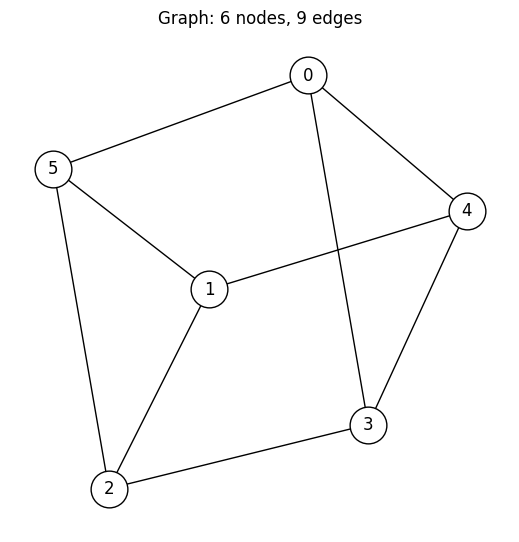

In [4]:
num_nodes = 6
# 三角柱グラフ: 三角形{0, 3, 4}と{1, 2, 5}を完全マッチング(0-5, 1-4, 2-3)で繋いだ
# ものです。2つの三角形を分離すればマッチングの3辺だけを切れば済みますが、それ以外の
# 等分割は必ず三角形を壊すため切断辺数が増えます。したがって最適な分割は一意です。
edge_list = [
    [0, 3],
    [0, 4],
    [0, 5],
    [1, 2],
    [1, 4],
    [1, 5],
    [2, 3],
    [2, 5],
    [3, 4],
]

G = nx.Graph()
G.add_nodes_from(range(num_nodes))
G.add_edges_from(edge_list)
assert G.number_of_nodes() == num_nodes
assert G.number_of_edges() == len(edge_list)

pos = nx.spring_layout(G, seed=1)
plt.figure(figsize=(5, 5))
nx.draw(G, pos, with_labels=True, node_color="white", node_size=700, edgecolors="black")
plt.title(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
plt.show()

In [5]:
instance_data = {"V": num_nodes, "E": edge_list}
instance = problem.eval(instance_data)

## アルゴリズム

ConverterはIsingコストハミルトニアン$H$をblock encodingし、$H - \mu I$のための2つ目のLCUを合成したうえで、QSVT多項式$p \approx \mathrm{sign}$を適用します。Hadamard testのための量子ビットを1つ加えると、こうして得られた鏡映がprojector$P_\mu$になります。一様重ね合わせ$|\varphi_0\rangle = H^{\otimes n}|0\rangle$から出発したとき、すべてのancillaが0と測定されるショットの割合は次の量を推定します。

$$P(\mu)=\lVert P_\mu |\varphi_0\rangle \rVert^2 = \frac{\#\{i : E_i < \mu\}}{2^n},$$

これは$\mu$より下にあるスペクトルの割合です。この1つの数値が、古典的な二分探索に必要な述語になります。$|\varphi_0\rangle$のなかで$\mu$より下の固有状態が重みを持つときに限り、この値は0から離れた値をとります。


## `QSVTFilterConverter()`を使う

`QSVTFilterConverter()`は問題インスタンスに対して呼び出すだけで使えます。ただし内部のパラメータの多くが解の品質を左右します。本チュートリアルではそれぞれのパラメータを説明し、解の品質を高めるための選び方も紹介します。

Isingハミルトニアンの定数項はblock encodingから除いてあります。この手法の性能は正規化パラメータ($\alpha$)に依存しており、定数項はこの値を大きくしてしまうためです。一方で定数のオフセットはすべての固有値を等しくずらすだけなので、解そのものには影響しません。`normalization`($\alpha$)と`energy_offset`($c$)の2つが揃ってスペクトルの範囲を与え、閾値はこの区間のなかから選ぶことになります。

In [6]:
converter = QSVTFilterConverter(instance)
transpiler = QiskitTranspiler()

low = converter.energy_offset - converter.normalization
high = converter.energy_offset + converter.normalization
print(f"alpha={converter.normalization}  offset={converter.energy_offset}")
print(f"every eigenvalue lies in [{low}, {high}]")

# 参照用スペクトル: Ising演算子は対角なので、正確なエネルギーを直接読み取って
# あとから探索結果を検証できます。
# !!! これは検証のためだけの計算であり、一般には指数時間かかります。
spin = converter.spin_model
energies = np.full(1 << spin.num_bits, float(spin.constant))
for state in range(energies.size):
    for word, coeff in spin.coefficients.items():
        parity = sum((state >> i) & 1 for i in word) & 1
        energies[state] += coeff * (-1.0 if parity else 1.0)

ground_energy = float(energies.min())
degeneracy = int((energies == ground_energy).sum())
print(f"levels={np.unique(energies)}  ground={ground_energy} ({degeneracy}-fold)")

assert low <= energies.min() and energies.max() <= high

alpha=3.0  offset=6.0
every eigenvalue lies in [3.0, 9.0]
levels=[3. 5. 7. 9.]  ground=3.0 (2-fold)


### 閾値を1つ試す

`transpile`は$\mu$を回路に埋め込むため、閾値ごとに個別のコンパイルが必要です。フィルタはデフォルトで$\mu$より*下*の固有空間を残します。これは最小固有値(基底エネルギー)を探索したい場合に必要な向きです。

`degree`と`delta`は対で決まります。`delta`は多項式の遷移領域の幅を定め、`degree`はChebyshev展開の次数で、その遷移を表現できるだけ大きくとる必要があります。

::: 指定しない場合、`degree`と`delta`にはConverterがデフォルト値を設定します。

分解能は次の式で与えられます。
$$
\Delta = \frac{\min_i |E_i-\mu|}{\alpha + |\mu - c|}
$$
ここで$E_i$は固有値で、その他のパラメータはこれまでに定義したものです。分解能を知るには基底エネルギーを事前に知っている必要がある、という状況がしばしば起こります。実際には分解能を上回るように、値を「推測」するか上界を見積もることになります。`degree`はおおよそ$O(1/\Delta)$で増えます。

以下では$\mu=4$としてアルゴリズムを実演します。このとき上回るべき分解能は$\Delta = \frac{|4-3|}{3 + |4 - 6|} = 1/5$であり、`delta=8`とすれば遷移領域の幅がこのギャップに合い、`degree=21`でそれを表現できます。対の取り方を誤っても精度が静かに落ちるわけではなく、$|p| \le 1$のチェックによってその場で棄却されます。

In [7]:
DEGREE, DELTA = 21, 8


def probe(mu, shots=2000):
    """`mu`より下にあるスペクトルの割合を推定します。"""
    executable = converter.transpile(
        transpiler,
        mu=mu,
        degree=DEGREE,
        delta=DELTA,
    )
    result = executable.sample(transpiler.executor(), shots=shots).result()
    return converter.success_probability(result)


# 64状態のうち2つが基底エネルギーにあるため、muがそこを超えると述語は
# 2 / 64で頭打ちになります。
print(f"p(mu=4.0) = {probe(4.0):.4f}   (exact: {(energies < 4.0).mean():.4f})")

[qamomile.qsvt_filter] synthesizing sign filter: degree=21, delta=8, scale=-1.1 -> 22 phases


p(mu=4.0) = 0.0295   (exact: 0.0312)


パラメータから定まる多項式近似に対応する位相因子の計算には、外部ライブラリの`pyqsp`を使っています。

Converterはprojectorの量子回路を構築します。その回路を実行し、サンプルのカウントから`success_probability`メソッドで成功確率を求めます。(精度の確認のため、参照として厳密計算の値も併記しています)

## 構成要素

`transpile`は3つの回路を入れ子に合成します。その順に描画すると、block encodingがどのようにprojectorへ変わっていくかが分かります。

図を読みやすく保つため、位相ベクトルは4要素に短くしてあります(上で使った22要素ではありません)。

In [8]:
DRAW_MU = 4.0

# `_shifted_encoding`は内部APIであり、Converterの公開APIには含まれません。
# ただし以下の回路はすべてこのdescriptorから構築されるため、この閾値で実際に
# 動く回路と図が一致します。
shifted = converter._shifted_encoding(DRAW_MU)
n_signal = shifted.num_signal_qubits
n_system = shifted.num_system_qubits

# degree=21のフィルタが使う22個ではなく4個の位相を使います。回路の形に効くのは
# 位相の個数だけで、値そのものは影響しません。
phi_demo = [0.1, 0.2, 0.3, 0.4]

print(f"alpha' = {shifted.normalization}   signal={n_signal}  system={n_system}")

alpha' = 5.0   signal=4  system=6


### 1. block encoding $U$

Isingハミルトニアンはユニタリの線形結合として書かれ、$\operatorname{PREPARE}$、$\operatorname{SELECT}$、$\operatorname{PREPARE}^\dagger$として実現されます。$\operatorname{PREPARE}$は係数の振幅をsignalレジスタに載せ、$\operatorname{SELECT}$はsignalの状態に応じて対応するPauli-$Z$の語をsystemに作用させ、$\operatorname{PREPARE}^\dagger$がそれをuncomputeします。

得られるのは、左上のブロック、つまりsignalレジスタがすべて0と測定される部分が$(H - \mu I)/\alpha'$となるようなユニタリです。そのブロックの外側は利用できないため、すべてのショットをそこでpost-selectする必要があります。

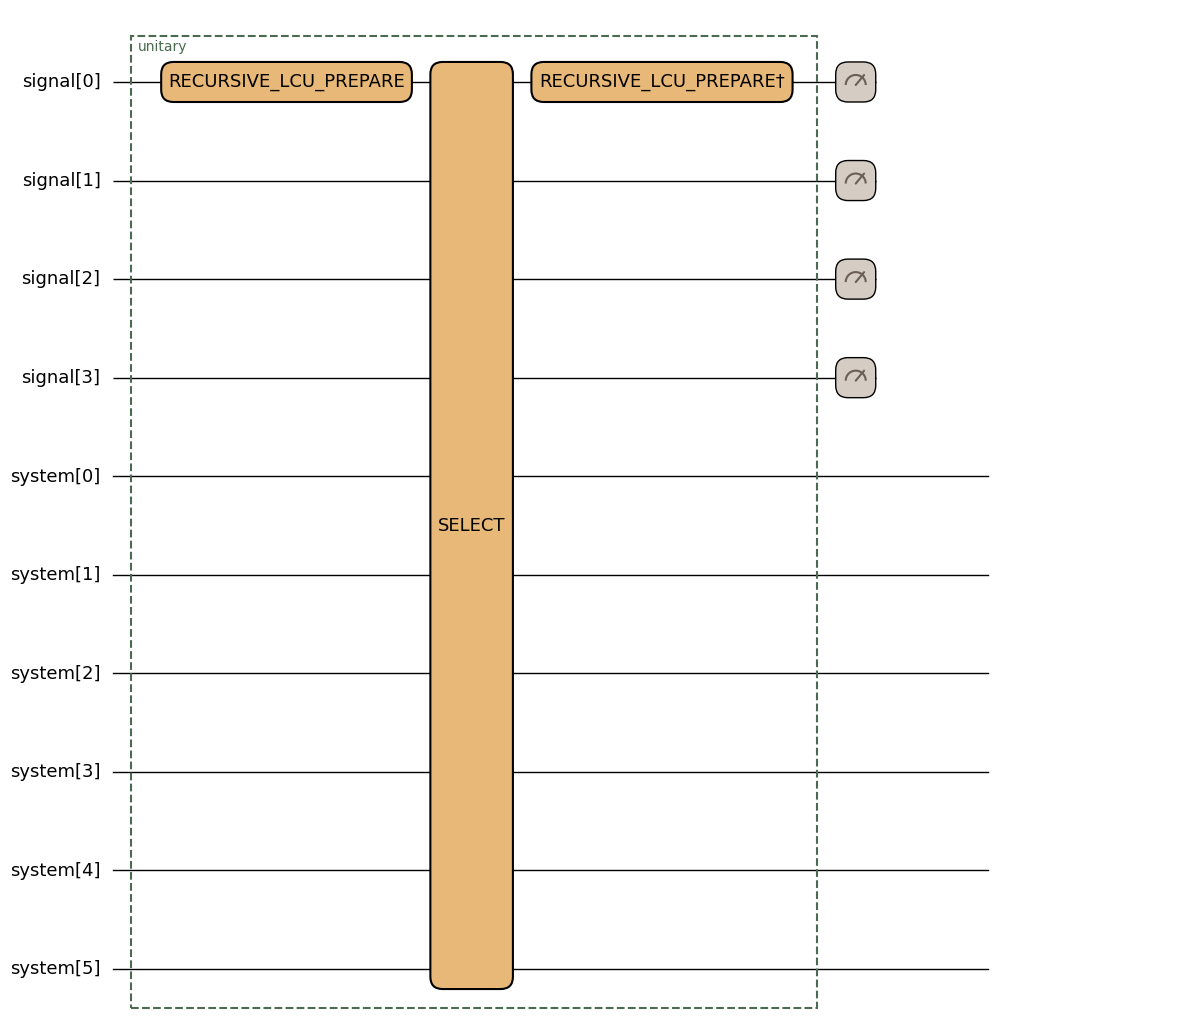

In [9]:
@qmc.qkernel
def block_encoding() -> qmc.Vector[qmc.Bit]:
    """(H - mu*I) / alpha'のblock encodingを|0>に作用させます。"""
    signal = qmc.qubit_array(n_signal, "signal")
    system = qmc.qubit_array(n_system, "system")
    signal, system = shifted.unitary(signal, system)
    return qmc.measure(signal)


block_encoding.draw(inline=True, inline_depth=1, fold_loops=False)

### 2. QSVTの交替列

block encodingが与えられると、`qmc.qsvt`は次を適用します。

$$R(\phi_0),\; U,\; R(\phi_1),\; U^\dagger,\; R(\phi_2),\; U,\; \dots$$

ここで$U$は上で構築したblock encoding、$R(\phi) = e^{i\phi(2\Pi - I)}$であり、$\Pi$はsignalレジスタをすべて0の状態へ射影します。この一連の列はすべてprimitiveが担当します。位相回転用の補助量子ビットを自前で確保し、$U$と$U^\dagger$を交互に並べ、位相を適用します。

その効果は、encodeされた演算子をその多項式で置き換えることです。`pyqsp`が生成した位相を使うと、この多項式は$\mathrm{sign}$を近似するため、良いブロックは$\mu$の片側の固有空間に関する*鏡映*になります。

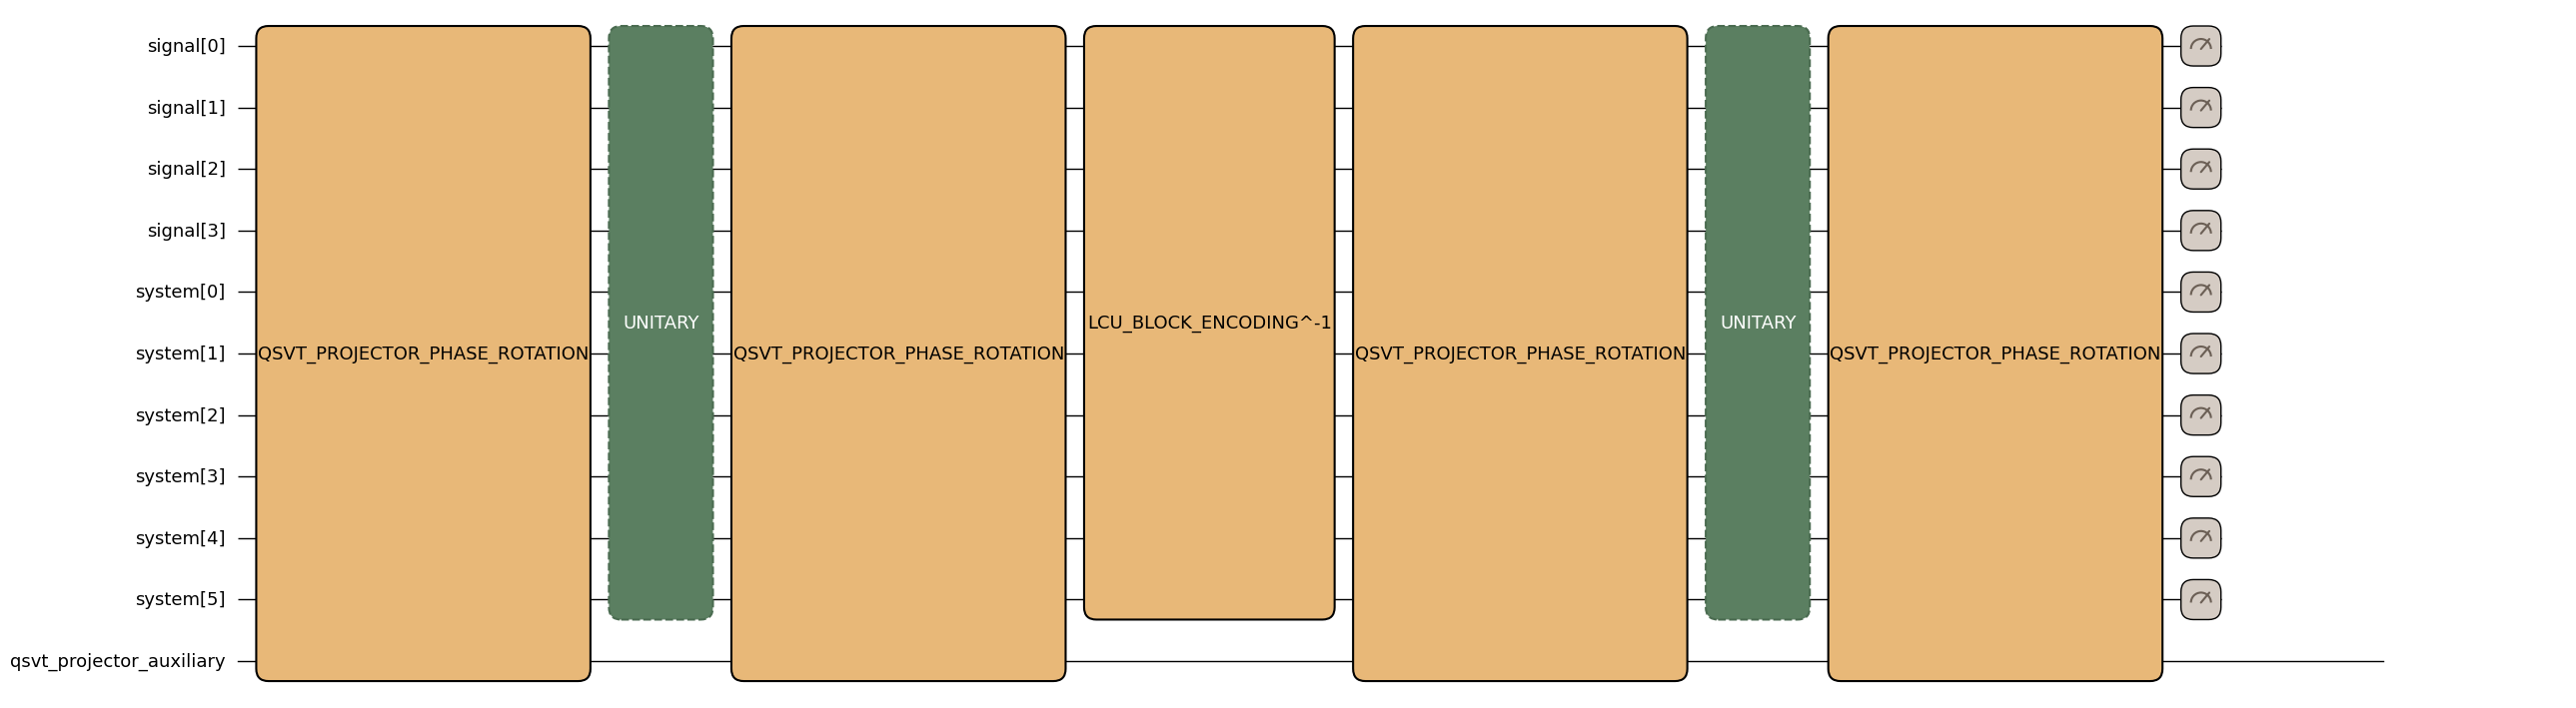

In [10]:
@qmc.qkernel
def qsvt_reflector(
    phi: qmc.Vector[qmc.Float],
) -> tuple[qmc.Vector[qmc.Bit], qmc.Vector[qmc.Bit]]:
    """sign((H - mu*I) / alpha')を実現するQSVTの交替列です。"""
    signal = qmc.qubit_array(n_signal, "signal")
    system = qmc.qubit_array(n_system, "system")
    signal, system = qmc.qsvt(signal, system, phi, shifted)
    return qmc.measure(signal), qmc.measure(system)


qsvt_reflector.draw(phi=phi_demo, inline=True, inline_depth=0, fold_loops=False)

### 3. Lin & Tongのprojector

目標は、この鏡映を射影$P_\mu = (I \pm R)/2$に変えることです。しかしこのprojectorは**ユニタリではない**ため、回路でそのまま適用することはできません。

鍵になるのは、これが$I$と$R$という2つのユニタリの和である点です。そのためHadamard testを使えば確率的に実現できます。1つのprobe量子ビットを重ね合わせにし、その*制御のもとで*QSVTの鏡映を作用させ、2つ目のHadamardで2つの分岐を干渉させます。probe量子ビットが0と測定されれば、$P_\mu$が作用した分岐であることが分かります。このアルゴリズムに成功確率という概念があるのはそのためであり、post-selectionをprobeと signalレジスタの**両方**に対して行う理由もここにあります。

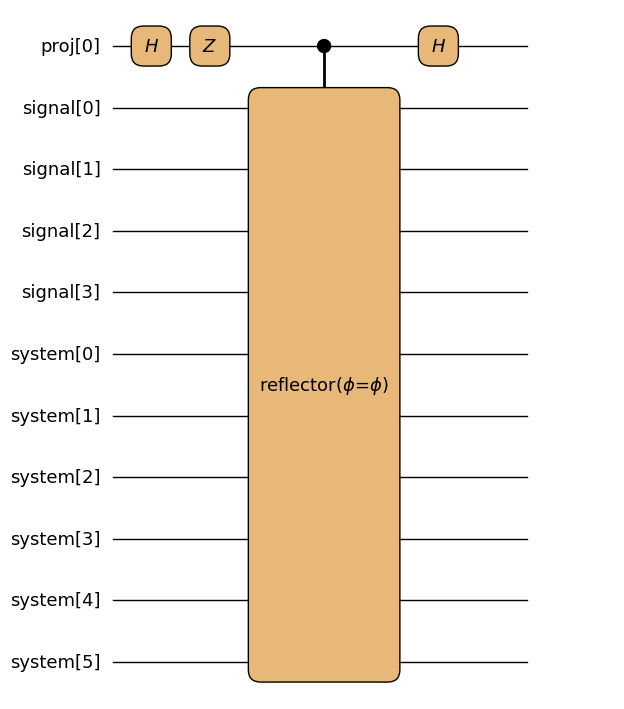

In [11]:
eigenstate_filter_projector(shifted).draw(
    proj=1,
    signal=n_signal,
    system=n_system,
    phi=phi_demo,
    inline=True,
    inline_depth=0,
    fold_loops=False,
)

## 二分探索

ここまでのアルゴリズムを使って、問題の解、すなわちハミルトニアンの基底状態に対する狭い範囲を求めます。そのために、Lin & Tongの論文と同じ二分探索アルゴリズムで閾値パラメータ$\mu$の適切な値を探します。

固有値が存在する範囲$[c-\alpha,c+\alpha)$はすでに計算しました。ある閾値$\mu$について、基底エネルギー$\lambda_0$と比較して考えます。$\mu$が$[c-\alpha, \lambda_0)$にあるときは固有値がすべて除かれ、$P(\mu)=0$となります。区間$[\lambda_0,\lambda_1)$では基底エネルギーだけが残ります。ハミルトニアンが対角なので、この確率は$\gamma^2 = d/2^n$で与えられます。ここで$n$は空間のサイズ、$d$は基底状態の縮退度です。区間$[\lambda_1,c+\alpha)$では、確率$P(\mu)$は常に$\gamma^2$より大きくなります。

パラメータ$\gamma$は探索が成功するための鍵ですが、$\gamma$の値は未知なので近似する必要があります。

$\gamma$が決まったら、探索空間$[c-\alpha,c+\alpha)$を等間隔のグリッドに分割します。空間の幅を$G$、離散化パラメータをアルゴリズムの入力$h$とすると、グリッドは$\mu$の候補を$\lfloor G/h \rfloor$個持ちます。この候補を古典的な二分探索で調べます。現在の閾値より上と下のどちらを探すかは、量子アルゴリズムで推定した$P(\mu)$が$\tau = \gamma^2/2$より大きいか小さいかで判断します。

$h$も慎重に選ぶ必要があり、(未知の)スペクトルギャップより小さくしなければなりません。

最後に、近似誤差によって関数が狭義単調にならない場合がある点に注意してください。これに対処するため、グリッド上の連続する2つの閾値を組にして評価し、$P(\mu) > \tau$かどうかを示すビットを$(B_k,B_{k+1})$として求め、その組に応じて範囲を動かします。

In [12]:
def binary_search_ground_energy(success_prob, low, high, gamma, h=1.0):
    """Lin & TongのAlgorithm 1: (B_k, B_k+1)を組にした評価。

    グリッドx_k = low + (k + 0.5) * h: 半セル分ずらすことで閾値が固有値の
    あいだに来ます。述語の比較は狭義なので、固有値の上にちょうど乗った閾値は
    0と判定されてしまうためです。B_k = 1となるのは、推定確率が
    tau = gamma**2 / 2を超えるときです。

    組で評価するループは最大4セルまで範囲を狭めます。そこから線形に走査して
    仕上げるので、返される範囲は1セル幅になります。
    戻り値は(x_L, x_U)で、x_L <= lambda_0 <= x_Uを満たします。左端を含むのは、
    基底エネルギーがちょうど`low`にある場合でも範囲に収めるためです。
    """
    n_grid = int(round((high - low) / h))
    grid = [low + (k + 0.5) * h for k in range(n_grid)]
    tau = 0.5 * gamma**2
    cache = {}

    def B(k):
        # 番兵: B_-1 = 0 (下に何もない)、B_G = 1 (すべてが下にある)。
        if not 0 <= k < n_grid:
            return 0 if k < 0 else 1
        if k not in cache:
            cache[k] = success_prob(grid[k])
        return int(cache[k] > tau)

    L, U = 0, n_grid - 1
    print(f"grid {grid[0]:+.2f}..{grid[-1]:+.2f}  G={n_grid}  h={h}  tau={tau:.4f}")

    while U - L > 3:
        k = (L + U) // 2
        bk, bk1 = B(k), B(k + 1)
        print(f"  k={k}: B({grid[k]:+.2f})={bk}  B({grid[k + 1]:+.2f})={bk1}", end="  ->  ")
        if bk == 1 and bk1 == 1:  # lambda_0 < x_k+1
            U = k + 1
            print(f"(1,1) U<-{U}  [{grid[L]:+.2f}, {grid[U]:+.2f}]")
        elif bk == 0 and bk1 == 0:  # lambda_0 > x_k
            L = k
            print(f"(0,0) L<-{L}  [{grid[L]:+.2f}, {grid[U]:+.2f}]")
        elif bk == 0 and bk1 == 1:  # x_k-1 < lambda_0 < x_k+2
            L, U = max(k - 1, 0), min(k + 2, n_grid - 1)
            print(f"(0,1) -> [{grid[L]:+.2f}, {grid[U]:+.2f}]")
            break
        else:  # x_k < lambda_0 < x_k+1
            L, U = k, k + 1
            print(f"(1,0) -> [{grid[L]:+.2f}, {grid[U]:+.2f}]")
            break

    # 1セルまで絞り込みます。述語が最初に立つグリッド点が、基底の固有空間を
    # まだ捉えている最小の閾値です。スペクトルの下界でクリップすることで範囲が
    # 物理的に意味のあるものになります。`low`より下に固有値は存在しないので、
    # そこを評価する必要はありません。
    for k in range(L, U + 1):
        if B(k):
            print(f"  refine: first B=1 at k={k} ({grid[k]:+.2f})")
            return max(grid[k] - h, low), grid[k]
    return grid[U], min(grid[U] + h, high)

In [13]:
gamma = np.sqrt(degeneracy / energies.size)
x_lower, x_upper = binary_search_ground_energy(probe, low, high, gamma=gamma, h=1.0)

print(f"\nlambda_0 in [{x_lower:+.2f}, {x_upper:+.2f}]   true lambda_0 = {ground_energy:+.2f}")

grid +3.50..+8.50  G=6  h=1.0  tau=0.0156


  k=2: B(+5.50)=1  B(+6.50)=1  ->  (1,1) U<-3  [+3.50, +6.50]


  refine: first B=1 at k=0 (+3.50)

lambda_0 in [+3.00, +3.50]   true lambda_0 = +3.00


## 補足

最後に、二分探索が見つけた最終的な閾値パラメータで量子アルゴリズムを呼び出せば、高い精度で基底状態を準備できます。その測定サンプルから最適解を取り出します。

::: 注: 二分探索で$P(\mu)>\tau$を判定するだけならフィルタがぼやけていても許容できるため、どの評価でも`degree=21`で十分でした。一方、基底の固有空間*だけ*を残そうとすると、$\mu = 3.5$では最適な分解能が探索時の$0.20$ではなく$\Delta = 0.09$になるため、最後のデコードではより鋭い多項式を使います。`degree`だけを上げても改善しません。`degree=61`に噛み合わない`delta=20`を組み合わせると、`degree=41`と`delta=11`の組(91%)より*悪い*85%になります。

In [14]:
# 述語の判定にはdegree 21で足りましたが、状態そのものを取り出すには同じ閾値でも
# より鋭いフィルタが必要です。
DECODE_DEGREE, DECODE_DELTA = 41, 11

executable = converter.transpile(
    transpiler,
    mu=x_upper,
    degree=DECODE_DEGREE,
    delta=DECODE_DELTA,
)
result = executable.sample(transpiler.executor(), shots=20000).result()
sampleset = converter.decode_to_binary_sampleset(result)

kept = sum(sampleset.num_occurrences)
optimal = sum(
    n
    for e, n in zip(sampleset.energy, sampleset.num_occurrences)
    if np.isclose(e, ground_energy)
)
print(f"kept {kept} of {result.shots} shots, {optimal / kept:.1%} at the ground energy")

best = max(zip(sampleset.samples, sampleset.num_occurrences), key=lambda z: z[1])[0]
side = sorted(v for v, bit in best.items() if bit == 1)
cut = sum(1 for u, v in edge_list if best[u] != best[v])
print(f"most sampled partition: {side} | cut={cut}")

assert optimal / kept > 0.85
assert cut == 3 and len(side) == num_nodes // 2

[qamomile.qsvt_filter] synthesizing sign filter: degree=41, delta=11, scale=-1.1 -> 42 phases


kept 609 of 20000 shots, 89.0% at the ground energy
most sampled partition: [1, 2, 5] | cut=3


最終的なサンプル分布`sampleset`から、最も多くサンプルされた分割を取り出し、分割問題の解として採用します。2つの三角形$\{0,3,4\}$と$\{1,2,5\}$は同じ分割を表すため、実行ごとにどちらが最上位に来ることもあります。対応する目的関数値(最小カット)は$3$です。

## まとめ

本notebookでは次のことを行いました。

- `QSVTFilterConverter`を使ってグラフ分割問題のインスタンスをend-to-endで解き、JijModelingの問題定義から三角柱グラフの最適分割、すなわちマッチングの3辺だけを切る2つの三角形へたどり着きました。
- Converterが合成する3つの入れ子になった回路を1つずつ見ました。$H - \mu I$のLCU block encoding、それを$\mu$の片側の固有空間に関する鏡映へ変える`qmc.qsvt`の交替列、そしてその鏡映をprojectorへ変えるHadamard testです。projectorはユニタリではありません。このアルゴリズムに*成功確率*があるのも、すべてのショットをprobeとsignalレジスタの両方でpost-selectしなければならないのも、まさにこのためです。
- そのpost-selectionの割合をLin & Tongの述語として使い、古典的な二分探索に$\mu$を動かさせました。基底エネルギーの位置を一切教えないまま、3回の評価でその範囲を絞り込めました。閾値$\tau = \gamma^2/2$は初期状態の重なりの下界$\gamma$を仮定した値に依存します。これはアルゴリズムへの入力であって普遍的な定数ではなく、一般的な値を選んでいたら本notebookの基底準位は完全に見落とされていました。
- どのパラメータも結局は正規化されたギャップ$\Delta = \min_i |E_i - \mu| / \alpha'$という1つの数値に行き着くことを確認しました。`delta`はこれに合わせる必要があり、`degree`は`delta`を表現できるだけ大きくとる必要があり、グリッド間隔`h`はこれより小さくできず、状態の取り出しは述語の判定よりも高い分解能を要求します。Isingの定数項をblock encodingから外すことで$\Delta$を取り戻せます。`normalization`と`energy_offset`が対で報告されるのはそのためであり、閾値を選ぶ基準になるのは固有値ではなくこの2つです。